# 📓 Tutorial: Jupyter Notebook (and Friends)

This notebook **is** the tutorial: you are using it to learn how to use it. Run the cells one at a time with `Shift+Enter`, change the code, break things and try again.

**Contents**

1. What Jupyter is: notebook, server, kernel
2. Cells, modes and shortcuts
3. Code cells and kernel state
4. Markdown cells
5. Magic commands and shell commands
6. Rich output: tables, plots, HTML, widgets
7. Help, introspection and debugging
8. Kernels and environments
9. The `.ipynb` format, exporting and best practices
10. Installing Jupyter locally
11. JupyterHub: what it is, download and installation
12. Google Colab and how it relates to Jupyter
13. Wrap-up, cheat sheet and exercises

> ℹ️ **A note on versions.** Minimum requirements, version numbers and some install commands change over time. Where it matters, you will find a pointer to the official documentation: when in doubt, trust that.

> ⚠️ The installation cells (`pip install`, `sudo ...`) are **deliberately commented out or written as plain text blocks**: they do not touch your system unless you decide to run them.

---
## 1. What Jupyter is

**Jupyter** is an open source ecosystem for *interactive computing*: you write code in small pieces (cells), run it right away and see the result under the cell, alongside text, formulas, tables and plots. The name comes from **Ju**lia, **Pyt**hon and **R**, but many more *kernels* are available.

A notebook always involves **three actors**:

```
 ┌───────────────┐   HTTP/WebSocket   ┌──────────────────┐   messages   ┌──────────────┐
 │   Frontend    │ ◀────────────────▶ │  Jupyter Server  │ ◀──────────▶ │    Kernel    │
 │ (browser, VS  │                    │ (files, sessions,│              │ (runs the    │
 │  Code, Colab) │                    │  authentication) │              │  code)       │
 └───────────────┘                    └──────────────────┘              └──────────────┘
```

| Actor | What it does | Examples |
|---|---|---|
| **Frontend** | The interface you see: shows cells and outputs | JupyterLab, Notebook 7, VS Code, Colab |
| **Server** | Reads/saves `.ipynb` files, manages sessions and security | `jupyter lab`, `jupyter server` |
| **Kernel** | The process that *actually runs* the code and keeps its **state** (variables, imports) | `ipykernel` (Python), IRkernel (R), IJulia |

A **notebook** (`.ipynb`) is just a **JSON** file containing the cells, their outputs and some metadata. It does not contain the kernel: that is started separately.

The cell below shows the environment *this* kernel is running in. Run it with `Shift+Enter`.

In [1]:
import sys
import platform
import importlib.metadata as md

print("Python      :", sys.version.split()[0])
print("Interpreter :", sys.executable)      # the Python used by THIS notebook's KERNEL
print("System      :", platform.system(), platform.release())

# Which pieces of the Jupyter ecosystem are installed in this environment?
packages = ["ipykernel", "notebook", "jupyterlab", "jupyterhub",
            "nbformat", "nbconvert", "ipywidgets", "pandas", "matplotlib"]
print()
for name in packages:
    try:
        print(f"{name:12s}", md.version(name))
    except md.PackageNotFoundError:
        print(f"{name:12s}", "-- not installed --")

# Are we on Google Colab? (we will need this in section 12)
IN_COLAB = "google.colab" in sys.modules
print("\nAre we on Google Colab?", IN_COLAB)

Python      : 3.11.3
Interpreter : /home/stefano/PyCharm-projects/DS_AI/.venv/bin/python
System      : Linux 6.18.33.2-microsoft-standard-WSL2

ipykernel    7.3.0
notebook     -- not installed --
jupyterlab   4.6.4
jupyterhub   -- not installed --
nbformat     5.11.1
nbconvert    7.17.1
ipywidgets   -- not installed --
pandas       3.0.4
matplotlib   3.11.0

Are we on Google Colab? False


---
## 2. Cells, modes and shortcuts

There are three kinds of cell:

- **Code**: code run by the kernel (Python, by default).
- **Markdown**: formatted text (like this cell).
- **Raw**: text that is not interpreted (used by tools such as `nbconvert`).

Two **modes** (in Jupyter):

- **Edit mode** (green/blue border, blinking cursor): you are typing inside the cell. Enter it with `Enter`.
- **Command mode** (grey border): you act on cells as objects. Enter it with `Esc`.

| Action | Jupyter (Lab / Notebook) | Google Colab |
|---|---|---|
| Run cell and move to the next one | `Shift+Enter` | `Shift+Enter` |
| Run cell and stay there | `Ctrl+Enter` | `Ctrl+Enter` |
| Run and insert a cell below | `Alt+Enter` | `Alt+Enter` |
| Insert cell above / below *(command mode)* | `A` / `B` | `Ctrl+M A` / `Ctrl+M B` |
| Delete cell | `D` `D` | `Ctrl+M D` |
| Convert to Markdown / to code | `M` / `Y` | `Ctrl+M M` / `Ctrl+M Y` |
| Undo last cell operation | `Z` | `Ctrl+M Z` |
| Show all shortcuts | `H` | `Ctrl+M H` |

On macOS use `Cmd` instead of `Ctrl`. Shortcuts can vary between versions and interfaces: the right place to check them is the *Help → Keyboard Shortcuts* menu (or JupyterLab's *Command Palette*, `Ctrl+Shift+C`).

---
## 3. Code cells and kernel state

Two fundamental rules:

1. **The last expression** of a cell is displayed automatically as output (`Out[n]`). `print()` instead writes to the output stream.
2. **Variables live in the kernel, not in the cell**. A cell you run defines names that every other cell can use, *in the order you run them*, not in the order they appear on the page.

In [2]:
x = 10
y = 32
print("print writes here...")   # "stream" output
x + y                           # ...while the last expression shows up as Out[n]

print writes here...


42

In [6]:
# State lives in the kernel: run THIS cell several times and watch the counter.
try:
    counter += 1
except NameError:
    counter = 0        # first run: the variable does not exist yet
print("counter =", counter)

counter = 3


### ⚠️ The classic problem: hidden state

Because you can run cells in any order, a notebook can *look* correct while depending on variables defined in a cell that you later deleted or edited. The number in square brackets `In [n]` tells you the real execution order.

**Golden rule:** before sharing a notebook, use *Kernel → Restart Kernel and Run All Cells* (in Colab: *Runtime → Restart and run all*). If it does not work from scratch, it is not reproducible.

Other useful actions on the kernel:

| Action | Effect |
|---|---|
| **Interrupt** | Stops the running cell (useful for infinite loops) |
| **Restart** | Kills the kernel and starts a new one: **all variables are lost** |
| **Restart & Run All** | Restarts and runs everything from top to bottom |
| **Shutdown** | Turns the kernel off without restarting it |

---
## 4. Markdown cells

Markdown cells are "compiled" with `Shift+Enter` and reopened with a double click. They support:

- `# Heading`, `## Subheading`, ... for headings
- `**bold**`, `*italic*`, `` `code` ``, bulleted and numbered lists
- links `[text](https://example.org)` and images `![alt](path.png)`
- tables with `|`, quotes with `>`, code blocks with three backticks
- **LaTeX formulas** between dollar signs: `$e^{i\pi} + 1 = 0$` or as a block with `$$ ... $$`

Example formula: the sample mean is $\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i$.

In [7]:
# You can also generate Markdown from code: handy for automatic reports
from IPython.display import Markdown, display

mean = sum([3, 5, 10]) / 3
display(Markdown(f"""
### Computed result

The mean is **{mean:.2f}**, obtained as $\\frac{{3 + 5 + 10}}{{3}}$.

| Value | Square |
|---:|---:|
| 3 | 9 |
| 5 | 25 |
"""))


### Computed result

The mean is **6.00**, obtained as $\frac{3 + 5 + 10}{3}$.

| Value | Square |
|---:|---:|
| 3 | 9 |
| 5 | 25 |


---
## 5. Magic commands and shell commands

The **IPython** kernel adds special features that are not plain Python:

- `%command` = **line magic** (acts on the line)
- `%%command` = **cell magic** (acts on the whole cell; it must be *on the first line*)
- `!command` = runs an operating system **shell command**

You can list all of them with `%lsmagic`, and read the documentation of a magic with `%timeit?`.

Some very common magics:

| Magic | What it is for |
|---|---|
| `%timeit expression` | Measures execution time (repeating it several times) |
| `%%time` | Measures the time of the whole cell |
| `%who` / `%whos` | Lists the variables defined in the kernel |
| `%pwd`, `%cd`, `%ls` | Working directory and navigation |
| `%env` | Reads/sets environment variables |
| `%run script.py` | Runs a Python script inside the notebook |
| `%%writefile file.txt` | Writes the cell contents to a file |
| `%load_ext autoreload` + `%autoreload 2` | Automatically reloads modules you edit |
| `%matplotlib inline` | Shows matplotlib plots under the cell (already the default in recent versions) |
| `%pip install package` | Installs a package **in the kernel's environment** |

In [8]:
%timeit sum(range(10_000))

122 μs ± 3 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [9]:
%%time
total = 0
for i in range(2_000_000):
    total += i
print(total)

1999999000000
CPU times: user 115 ms, sys: 11.6 ms, total: 126 ms
Wall time: 123 ms


In [10]:
%whos

Variable       Type        Data/Info
------------------------------------
IN_COLAB       bool        False
Markdown       type        <class 'IPython.core.display.Markdown'>
counter        int         3
debugpy        module      <module 'debugpy' from '/<...>ers/debugpy/__init__.py'>
display        function    <function display at 0x76d1164b7e20>
i              int         1999999
md             module      <module 'importlib.metada<...>ib/metadata/__init__.py'>
mean           float       6.0
name           str         matplotlib
packages       list        n=9
platform       module      <module 'platform' from '<...>/python3.11/platform.py'>
runtime_vars   module      <module 'pycharm_jupyter.<...>jupyter/runtime_vars.py'>
sys            module      <module 'sys' (built-in)>
total          int         1999999000000
x              int         10
y              int         32


In [11]:
# Shell commands: the "!" hands them to the operating system
!python --version
!echo "Hello from the shell!"

# You can capture the output in a Python variable (a list of strings).
# On Windows replace "ls" with "dir".
files_here = !ls
print(len(files_here), "items in the current folder")

Python 3.11.3
Hello from the shell!
9 items in the current folder


### `%pip` and not `!pip`

In notebooks always install packages with **`%pip install ...`** (or `%conda install ...`), not with `!pip install ...`. The `%` version is tied to **the kernel in use**; `!pip` might instead call the `pip` of a different Python, and you would end up with "ModuleNotFoundError" even though you installed the package.

After installing a package that was already imported, you usually need to **restart the kernel**.

In [ ]:
# Uncomment to install (a small package here, as an example):
# %pip install tqdm

In [12]:
%%writefile hello.txt
This file was written by a notebook cell.
You will find "hello.txt" in the file browser on the left.

Writing hello.txt


---
## 6. Rich output: tables, plots, HTML, widgets

A notebook does not only show text: every object can decide *how* to display itself (HTML, images, LaTeX...). `display()` shows an object anywhere in the cell, while the last expression is displayed on its own.

In [13]:
from IPython.display import HTML, display

display(HTML("<b>You can display HTML</b>, even <span style='color:crimson'>colored</span>."))

In [14]:
# Tables: a pandas DataFrame "draws" itself as a formatted HTML table
try:
    import pandas as pd
    df = pd.DataFrame({
        "city": ["Milan", "Rome", "Turin"],
        "population_mln": [1.4, 2.8, 0.85],
    })
    df                      # last expression -> formatted table
except ImportError:
    print("pandas is not installed: try  %pip install pandas")

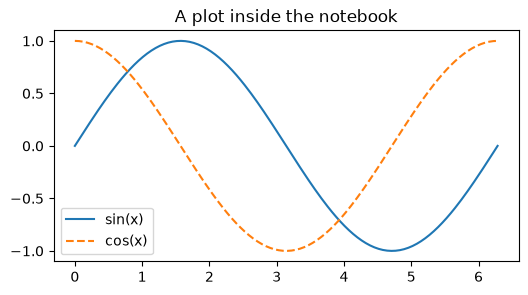

In [15]:
# Plots: matplotlib shows the figure directly under the cell
try:
    import numpy as np
    import matplotlib.pyplot as plt

    x = np.linspace(0, 2 * np.pi, 200)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.plot(x, np.sin(x), label="sin(x)")
    ax.plot(x, np.cos(x), label="cos(x)", linestyle="--")
    ax.legend()
    ax.set_title("A plot inside the notebook")
    plt.show()
except ImportError:
    print("numpy/matplotlib are not installed: %pip install numpy matplotlib")

In [16]:
# Interactive widgets: they change the output on the fly (require ipywidgets)
try:
    from ipywidgets import interact

    @interact(n=(1, 10))
    def square(n=3):
        print(f"{n}^2 = {n**2}")
except ImportError:
    print("ipywidgets is not installed: %pip install ipywidgets")

ipywidgets is not installed: %pip install ipywidgets


---
## 7. Help, introspection and debugging

Jupyter is built for exploring. Three gestures to learn right away:

- **`Tab`**: autocompletes names and attributes (`math.` + `Tab`).
- **`Shift+Tab`** inside a function's parentheses: shows the signature and docstring.
- **`?` and `??`** after a name: documentation (`?`) and source code (`??`).

In [17]:
import math

# The line below shows the documentation of math.hypot (works only in IPython/Jupyter).
# Also try "??" to see the source code, where available.
math.hypot?

In [18]:
help(math.sqrt)   # the "plain Python" equivalent
print()
print([n for n in dir(math) if not n.startswith("_")][:10], "...")   # exploring attributes

Help on built-in function sqrt in module math:

sqrt(x, /)
    Return the square root of x.


['acos', 'acosh', 'asin', 'asinh', 'atan', 'atan2', 'atanh', 'cbrt', 'ceil', 'comb'] ...


### Debugging

If a cell raises an exception, the notebook shows the **traceback** under the cell and the kernel stays alive. Right after an error you can run **`%debug`** in a new cell to open the `pdb` debugger at the point where the problem happened (inspect variables, move up and down the stack; `q` to quit). With `%pdb on` the debugger opens automatically on every error.

In [19]:
import traceback

def divide(a, b):
    return a / b

try:
    divide(1, 0)
except ZeroDivisionError:
    traceback.print_exc()   # in a normal cell, an unhandled error would show the same traceback

# After a real error, in a new cell:  %debug

Traceback (most recent call last):
  File "/tmp/ipykernel_7635/1372408287.py", line 7, in <module>
    divide(1, 0)
  File "/tmp/ipykernel_7635/1372408287.py", line 4, in divide
    return a / b
           ~~^~~
ZeroDivisionError: division by zero


---
## 8. Kernels and environments

Every notebook is connected to a **kernel**, and every kernel uses **one specific Python interpreter** (with its own packages). This is the point that causes the most confusion: *the package is installed... but not in the Python the kernel uses*.

To see the registered kernels:

In [20]:
!jupyter kernelspec list

Available kernels:
  python3        /home/stefano/PyCharm-projects/DS_AI/.venv/share/jupyter/kernels/python3
  .dsai_env      /home/stefano/.local/share/jupyter/kernels/.dsai_env
  gestionale     /home/stefano/.local/share/jupyter/kernels/gestionale
  pyagrum-env    /home/stefano/.local/share/jupyter/kernels/pyagrum-env
  slr-env        /home/stefano/.local/share/jupyter/kernels/slr-env


To make a specific **virtual environment** available in Jupyter, register it as a kernel (from the terminal, with the environment active):

```bash
python -m venv .venv
source .venv/bin/activate            # Windows: .venv\Scripts\activate
python -m pip install ipykernel
python -m ipykernel install --user --name my-project --display-name "Python (my-project)"
```

Then, in the *Kernel → Change Kernel* menu (on Colab this is not needed: the runtime is already chosen), select "Python (my-project)". Other languages have their own kernel (R, Julia, Bash, SQL, ...): the list is in the Jupyter documentation.

---
## 9. The `.ipynb` format, exporting and best practices

### What a notebook looks like inside

An `.ipynb` is JSON: a list of cells, each with a type, a source and (for code) outputs. Let's build a minimal one by hand and save it:

In [21]:
import json
from pathlib import Path

mini = {
    "cells": [
        {"cell_type": "markdown", "metadata": {}, "source": ["# Notebook created from code"]},
        {"cell_type": "code", "execution_count": None, "metadata": {},
         "outputs": [], "source": ["print('hello from the mini notebook!')"]},
    ],
    "metadata": {"kernelspec": {"name": "python3", "display_name": "Python 3", "language": "python"}},
    "nbformat": 4,
    "nbformat_minor": 4,
}

text = json.dumps(mini, indent=1, ensure_ascii=False)
Path("mini_example.ipynb").write_text(text, encoding="utf-8")
print(text[:400], "...")
print("\nSaved: open 'mini_example.ipynb' from the file browser.")

{
 "cells": [
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "# Notebook created from code"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "print('hello from the mini notebook!')"
   ]
  }
 ],
 "metadata": {
  "kernelspec": {
   "name": "python3",
   "display_name": "Python 3",
   "language": "python" ...

Saved: open 'mini_example.ipynb' from the file browser.


(The `nbformat` library does the same thing more safely: `nbformat.read()`, `nbformat.v4.new_notebook()`, `nbformat.write()`.)

### Exporting and automating with `nbconvert`

```bash
jupyter nbconvert --to html   notebook.ipynb     # web page
jupyter nbconvert --to script notebook.ipynb     # .py file
jupyter nbconvert --to pdf    notebook.ipynb     # PDF (needs LaTeX or the "webpdf" export)
jupyter nbconvert --to notebook --execute notebook.ipynb   # runs everything and saves the outputs
jupyter nbconvert --clear-output --inplace notebook.ipynb  # strips the outputs (useful before a commit)
```

Other common tools: **papermill** (runs notebooks with parameters, for scheduled pipelines), **jupytext** (pairs the notebook with a `.py`/`.md` file, handy with Git), **nbstripout** (removes outputs from commits).

### Best practices

1. **Reproducibility**: before sharing, *Restart & Run All*.
2. **Imports and configuration at the top**; set random seeds (`np.random.default_rng(42)`).
3. **Declare dependencies** (`requirements.txt`, `environment.yml`, or an initial `%pip install` cell).
4. **Never paste secrets** (passwords, API keys) into the notebook: use environment variables or, on Colab, *Secrets*.
5. **Small cells, one idea per cell**; move reusable code into importable `.py` modules.
6. **Names and Markdown**: a notebook reads like a document. Explain the *why*, not just the *how*.
7. **Version control**: outputs make diffs unreadable; use `nbstripout` or `jupytext`.
8. **Mind paths and data**: use relative paths and document where the data comes from.

---
## 10. Installing Jupyter locally

You only need **Python** installed. Pick *one* of the routes (all for a single user on their own computer).

### A) `pip` in a virtual environment (recommended)

```bash
python3 -m venv .venv
source .venv/bin/activate              # Windows: .venv\Scripts\activate
python -m pip install --upgrade pip
python -m pip install jupyterlab       # or: notebook
jupyter lab                            # opens http://localhost:8888
```

### B) `conda` / Miniforge

```bash
conda create -n jup -c conda-forge python jupyterlab
conda activate jup
jupyter lab
```

### C) `uv` (without installing anything permanently)

```bash
uv run --with jupyterlab jupyter lab
```

### D) "Turnkey" alternatives

- **Anaconda distribution**: includes Python, Jupyter and many scientific libraries.
- **VS Code** with the Jupyter extension: open an `.ipynb` directly in the editor.
- **JupyterLab Desktop**: a desktop application with Jupyter built in.

### JupyterLab or Notebook?

They are two interfaces on the same ecosystem. **JupyterLab** is a more IDE-like environment (multiple panels, terminal, file browser, text editor). **Jupyter Notebook** (version 7 and later) is the "one document at a time" interface, now built on JupyterLab components. The `.ipynb` files are identical and open in both.

### Useful commands

```bash
jupyter lab --no-browser --port 9999      # don't open the browser, change port
jupyter server list                       # running servers (with token)
jupyter --paths                           # where Jupyter looks for configs and kernels
jupyter server --generate-config          # creates the configuration file
```

> 🔒 **Security:** a Jupyter server lets people **run arbitrary code** on the machine. By default it listens only on `localhost` and is protected by a token. Do not expose it to the Internet (`--ip 0.0.0.0`) without authentication, HTTPS and a good reason: for shared use, JupyterHub exists.

---
## 12. Google Colab and how it relates to Jupyter

**Google Colab** (Colaboratory) is a **service hosted by Google** that lets you use Jupyter notebooks directly in the browser, **without installing anything**. It is based on Jupyter technology (`.ipynb` files, Python kernel, cells, magic commands) but it **is not JupyterLab**: it has its own interface, and the server and kernel run on Google's virtual machines.

### What it shares with Jupyter

- The **same format**, `.ipynb`: notebooks open in both (Colab adds some metadata, harmless for Jupyter).
- The same ideas: cells, kernel, `%magic`, `!shell`, rich output.
- The frontend → server → kernel architecture; in Colab the "server + kernel" is called the **runtime**.

### What changes

| Aspect | Jupyter / JupyterHub | Google Colab |
|---|---|---|
| Where the code runs | On your computer / your server | On Google's virtual machines (or, if you want, on a local runtime) |
| Installation | Yes (or handled by the administrator) | None, a Google account is required |
| Interface | JupyterLab / Notebook / VS Code | The Colab interface (browser-based) |
| Extensions | The JupyterLab extension ecosystem | Not available: Colab's own features instead |
| Files | Your disk | **Temporary** disk of the runtime (`/content`); Google Drive must be mounted |
| Environment persistence | Stays until you change it | The VM is recycled: installed packages and temporary files **are lost** |
| Hardware | What you have/manage | GPUs/TPUs available (limits depend on the plan and availability) |
| Collaboration | With JupyterHub/extra services | Google Docs-style sharing and comments |
| Cost | Free (you pay for the hardware) | Free tier with limits + paid plans |
| Data privacy | Under your control | Data and code go through Google's systems |

Colab's limits and plans change often: see the official FAQ for up-to-date details (session length, available GPUs, etc.).

### Colab, Jupyter, JupyterHub: where they fit

- **Jupyter** = the software and the format.
- **JupyterHub** = Jupyter for *many users* on your own infrastructure (school, company).
- **Colab** = Jupyter as a *managed service* run by Google, convenient for getting started, sharing and using GPUs without configuring anything.

They are not mutually exclusive: it is common to develop locally or on a Hub and use Colab to share a demo or for a one-off GPU.

In [23]:
# Recognizing the environment: useful for writing notebooks that work anywhere
import sys
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("You are on Google Colab.")
    print("Files in /content are temporary; to keep data, use Drive:")
    print("    from google.colab import drive; drive.mount('/content/drive')")
else:
    print("You are not on Colab: the 'google.colab' module is not available.")
    print("Files stay on your disk, in the notebook's folder.")

You are not on Colab: the 'google.colab' module is not available.
Files stay on your disk, in the notebook's folder.


In [ ]:
# A portable pattern for secrets: Colab has "Secrets", elsewhere you use environment variables.
import os

def read_secret(name):
    try:
        from google.colab import userdata          # exists only on Colab
        return userdata.get(name)
    except ImportError:
        return os.environ.get(name)                # local Jupyter / JupyterHub

key = read_secret("MY_KEY")
print("Key found?", key is not None)

In [ ]:
# Colab also supports "forms" in cells through special #@param comments.
# In Jupyter they are plain comments: the cell still works (with the value written here).
name = "world"      #@param {type:"string"}
repetitions = 3     #@param {type:"integer"}

for _ in range(repetitions):
    print(f"Hello, {name}!")

### Opening in Colab a notebook that lives on GitHub

If the notebook is in a public GitHub repository, you can open it in Colab with a URL like this:

```
https://colab.research.google.com/github/<user>/<repo>/blob/<branch>/<path>/notebook.ipynb
```

In a `README` people often add an "Open in Colab" badge (a Markdown link with the badge image pointing to that URL).

### Portability: a few precautions

- Do not take paths for granted: `/content/...` exists only on Colab.
- Put `%pip install` in an initial cell: on Colab the environment is reset when the runtime is recycled.
- Third-party widgets may require enabling a dedicated manager on Colab (`from google.colab import output; output.enable_custom_widget_manager()`).
- Test with *Restart & Run All* in both environments.

### Using Colab as the interface, but with *your* machine (local runtime)

Colab can connect to a **local runtime**: the code runs on your computer, the interface remains Colab's. The official documentation describes two routes: starting a **Docker container** provided by Colab, or running a **Jupyter server** that allows access from Colab's origin. Example (Docker, CPU):

```bash
docker run -p 127.0.0.1:9000:8080 us-docker.pkg.dev/colab-images/public/cpu-runtime
```

Then in Colab: *Connect → Connect to a local runtime* and paste the URL with the token shown by the container. A notebook connected to a local runtime can read, write and delete files on your computer: **use it only with notebooks you trust**. The exact procedure (command, port, options) may change: follow the *Local runtimes* page of the Colab documentation.

### Other variants in the ecosystem

| Tool | In short |
|---|---|
| **Binder / BinderHub** | Turns a Git repository into a temporary, shareable Jupyter environment reachable through a link |
| **JupyterLite** | Jupyter running *entirely in the browser* (Python via WebAssembly), no server |
| **Kaggle Notebooks** | Notebooks hosted by Kaggle, with datasets and GPUs |
| **VS Code** | Editor with native notebook support, also against remote Jupyter servers; there is also an extension for using Colab runtimes |

---
## 13. Wrap-up

### What to use when

| Situation | Sensible choice |
|---|---|
| I'm learning/experimenting on my PC | JupyterLab locally (venv or conda) |
| A class or team with shared access, on a single server | The Littlest JupyterHub |
| Many users, variable load, cloud infrastructure | Z2JH on Kubernetes |
| I want to try quickly, share, or use a GPU without installing | Google Colab |
| I want people to try a repository "with one click" | Binder |

### Cheat sheet

```text
Shift+Enter   run and move on            %timeit       measure time
Esc / Enter   command / edit mode        %%time        time the whole cell
A / B         cell above / below         %whos         variables in the kernel
D D           delete cell                %pip install  install into the current kernel
M / Y         Markdown / code            !command      operating system shell
Tab           autocomplete               ?  /  ??      documentation / source
Shift+Tab     show the docstring         %debug        debugger after an error
```

### Exercises

1. **Kernel state.** Define a variable in a cell, restart the kernel and re-run only the cell that uses it. What happens? Then try *Restart & Run All*.
2. **Markdown.** Create a Markdown cell with a heading, a list, a table and a LaTeX formula (for example the quadratic formula).
3. **Magic.** Use `%timeit` to compare a `for` loop and a list comprehension that compute the squares from 0 to 999.
4. **Environment.** Create a virtual environment, register it as a kernel with `ipykernel` and check with `sys.executable` that the notebook is using it.
5. **Export.** Export this notebook to HTML with `jupyter nbconvert` and open it in the browser.
6. **JupyterHub.** On a virtual machine or in WSL/Docker, try the example configuration from section 11.3 (`jupyterhub -f jupyterhub_config.example.py`) and log in as `admin`.
7. **Colab.** Upload this notebook to Google Drive (or GitHub) and open it in Colab: which cells behave differently? Why?

### Resources

- Project Jupyter: `jupyter.org` and `docs.jupyter.org`
- JupyterHub: `jupyterhub.readthedocs.io`
- The Littlest JupyterHub: `tljh.jupyter.org`
- Zero to JupyterHub with Kubernetes: `z2jh.jupyter.org`
- Google Colab: `colab.research.google.com` (and the *FAQ* and *Local runtimes* pages of the documentation)

Happy hacking! 🚀